# 00 - Análisis exploratorio de teledetección, datos y metodología

Proyecto: MethaneProjectTFM.

Este notebook documenta el análisis exploratorio previo al entrenamiento de modelos de segmentación para detección de plumas de metano.

Objetivos:

- Entender la estructura del dataset.
- Revisar disponibilidad de productos por muestra.
- Analizar bandas espectrales y features derivadas.
- Revisar distribución de plumas.
- Justificar ConfigB con MBMPPlus no supervisado.
- Verificar que Plume/GroundTruth no se usan para construir features.

Flujo general del proyecto:

0. EDA y metodología.
1. Pipeline controlado.
2. Comparación de resultados.
3. Decisión de modelo.
4. Escritura del documento.

## 1. Configuración inicial

Este notebook debe ejecutarse desde la raíz del repositorio:

`cd /data/users/kabasmen/MethaneProjectTFM`

In [5]:
from pathlib import Path
import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ProjectRoot = Path("/data/users/kabasmen/MethaneProjectTFM")
sys.path.append(str(ProjectRoot))

from Source.TacoIndex import LoadTacoDataset, GetSampleTable
from Source.ReadTacoSample import ReadFullTacoSample
from Source.FeatureEngineering import BuildFeatureDictionary, BuildFeatureStack

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("ProjectRoot:", ProjectRoot)

ProjectRoot: /data/users/kabasmen/MethaneProjectTFM


## Estilo visual oficial del proyecto

Se aplica el estilo definido en `Source/VisualizationStyle.py` y en `Configs/VisualizationConfig.yaml`.

Esto permite que las figuras del EDA sean consistentes con los reportes HTML y con las figuras finales del documento.

In [6]:
from Source.VisualizationStyle import (
    LoadVisualizationConfig,
    ApplyMatplotlibStyle,
    GetFigureSize,
    GetSaveParameters,
)

VisualizationConfig = LoadVisualizationConfig(
    ConfigPath=ProjectRoot / "Configs" / "VisualizationConfig.yaml"
)

ApplyMatplotlibStyle(VisualizationConfig)

print("VisualizationConfig loaded.")
print("Font family:", VisualizationConfig.get("Visualization", {}).get("FontFamily"))
print("Available figure sizes:", VisualizationConfig.get("Visualization", {}).get("FigureSizes", {}).keys())

VisualizationConfig loaded.
Font family: Montserrat
Available figure sizes: dict_keys(['Single', 'Panel1x3', 'Panel2x3', 'Panel3x4', 'ArticlePanel'])


## Estilo de figuras para documentación

Las siguientes funciones estandarizan las figuras del EDA para que puedan usarse posteriormente en el documento.

El estilo busca ser consistente con las figuras comparativas del proyecto: azules, fuente limpia, grid suave, bordes visibles y exportación a PNG.

In [7]:
RunTag="Exp242351"

In [8]:

# =============================================================================
# Thesis/report figure style helpers
# =============================================================================

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

FIGURE_DIR = ProjectRoot / "Outputs" / "Experiments" / RunTag / "EDA" / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "dark": "#123B7A",
    "navy": "#0B2E6F",
    "blue": "#2E86DE",
    "light_blue": "#5DB7E8",
    "cyan": "#7AD7E5",
    "pale_blue": "#AFC8E6",
    "mid_blue": "#6F96C6",
    "grid": "#D8E8F7",
    "text": "#172B4D",
    "border": "#54B4F5",
}

SPLIT_COLORS = {
    "Train": COLORS["navy"],
    "Validation": COLORS["light_blue"],
    "Test": COLORS["cyan"],
}

REGION_COLORS = {
    "Plume": COLORS["navy"],
    "Background": COLORS["light_blue"],
    "All": COLORS["mid_blue"],
}

def ApplyThesisFigureStyle():
    """Aplica estilo global para figuras de tesis/documento."""
    mpl.rcParams.update({
        "font.family": VisualizationConfig.get("Visualization", {}).get("FontFamily", "DejaVu Sans"),
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": COLORS["border"],
        "axes.linewidth": 1.4,
        "axes.labelcolor": COLORS["text"],
        "axes.titlecolor": COLORS["navy"],
        "xtick.color": COLORS["text"],
        "ytick.color": COLORS["text"],
        "text.color": COLORS["text"],
        "axes.grid": True,
        "grid.color": COLORS["grid"],
        "grid.alpha": 0.65,
        "grid.linewidth": 0.8,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "axes.titlesize": 18,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 20,
    })

def StyleAxes(ax, title=None, xlabel=None, ylabel=None):
    """Aplica estilo de eje consistente."""
    if title is not None:
        ax.set_title(title, fontsize=18, fontweight="bold", color=COLORS["navy"], pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=14, color=COLORS["text"])
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=14, color=COLORS["text"])

    for spine in ax.spines.values():
        spine.set_color(COLORS["border"])
        spine.set_linewidth(1.4)

    ax.grid(True, color=COLORS["grid"], alpha=0.65, linewidth=0.8)
    return ax

def SaveFigure(fig, filename, dpi=220):
    """Guarda figura en carpeta EDA/Figures."""
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("Saved figure:", path)
    return path

def ThesisBarLabels(ax, fmt="{:.3f}", rotation=90):
    """Agrega etiquetas sobre barras."""
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            try:
                labels.append(fmt.format(value))
            except Exception:
                labels.append(str(value))
        ax.bar_label(container, labels=labels, padding=4, rotation=rotation, fontsize=11, color=COLORS["text"])

def GetThesisFigSize(kind="wide"):
    sizes = {
        "wide": (14, 7),
        "compact": (11, 6),
        "large": (14, 11),
        "heatmap": (12, 9),
        "grid": (15, 12),
    }
    return sizes.get(kind, sizes["wide"])

ApplyThesisFigureStyle()
print("Thesis figure style ready.")
print("Figure output directory:", FIGURE_DIR)


Thesis figure style ready.
Figure output directory: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp242351/EDA/Figures


In [9]:
def GetFigureSizeSafe(SizeName="Default", Fallback=(10, 6)):
    """Devuelve tamaño de figura desde VisualizationConfig o fallback si no existe."""
    try:
        return GetFigureSize(VisualizationConfig, SizeName)
    except Exception:
        sizes = VisualizationConfig.get("Visualization", {}).get("FigureSizes", {})
        if sizes:
            first_key = list(sizes.keys())[0]
            try:
                return GetFigureSize(VisualizationConfig, first_key)
            except Exception:
                pass
        return Fallback

print("FigureSizes disponibles:", VisualizationConfig.get("Visualization", {}).get("FigureSizes", {}).keys())

FigureSizes disponibles: dict_keys(['Single', 'Panel1x3', 'Panel2x3', 'Panel3x4', 'ArticlePanel'])


## 2. Configuración del proyecto

Se carga `Configs/ProjectConfig.yaml` para identificar ruta del dataset y nombre del dataset.

In [10]:
ConfigPath = ProjectRoot / "Configs" / "ProjectConfig.yaml"

with open(ConfigPath, "r", encoding="utf-8") as f:
    ProjectConfig = yaml.safe_load(f)

ProjectConfig

{'ProjectName': 'MethaneProjectTFM',
 'Seed': 42,
 'Dataset': {'DataRoot': '/data/databases/METHANE_DATASETS_TACOv2',
  'DatasetName': 'methaneset-s2-finetune'},
 'Outputs': {'Root': 'Outputs/Experiments'},
 'RunTag': {'Pattern': '^Exp[0-9]{6}$', 'Example': 'Exp241930'},
 'Filters': {'Sector': 'Oil and Gas',
  'MinPercentageClear': 90.0,
  'Observability': 'clear',
  'RequirePlume': True,
  'RequireGeometry': True,
  'RequireProducts': ['target', 'reference', 'plume']},
 'Split': {'Train': 0.7, 'Validation': 0.15, 'Test': 0.15},
 'ExpectedShapes': {'Target': [13, 200, 200],
  'Reference': [13, 200, 200],
  'Plume': [200, 200],
  'CH4': [200, 200]},
 'Experiment': {'Configs': ['ConfigA', 'ConfigB', 'ConfigC']}}

In [11]:
if "Dataset" in ProjectConfig:
    DataRoot = ProjectConfig["Dataset"]["DataRoot"]
    DatasetName = ProjectConfig["Dataset"]["DatasetName"]
else:
    DataRoot = ProjectConfig["DataRoot"]
    DatasetName = ProjectConfig["DatasetName"]

print("DataRoot:", DataRoot)
print("DatasetName:", DatasetName)

DataRoot: /data/databases/METHANE_DATASETS_TACOv2
DatasetName: methaneset-s2-finetune


## 3. Carga del dataset TACO

La lectura oficial debe hacerse con `LoadTacoDataset` y `GetSampleTable`.

Importante: `ReadFullTacoSample` necesita el objeto Dataset real, no un CSV.

In [12]:
Dataset, DatasetInfo = LoadTacoDataset(DataRoot, DatasetName)
SampleTable = GetSampleTable(Dataset)

print("Dataset type:", type(Dataset))
print("SampleTable shape:", SampleTable.shape)
display(SampleTable.head())

Dataset type: <class 'tacoreader.dataset.TacoDataset'>
SampleTable shape: (3612, 39)


,id,type,detection:case_study,detection:ch4_fluxrate,detection:ch4_fluxrate_std,detection:isplume,detection:offshore,detection:sector,detection:wind_source,geoenrich:admin_countries,geoenrich:admin_districts,geoenrich:admin_states,geoenrich:elevation,geoenrich:population,geoenrich:temperature,majortom:code,meteo:wind_u,meteo:wind_v,plume:geometry,quality:last_update,quality:notified,quality:observability,quality:percentage_clear,satellite:background_tile,satellite:platform,satellite:sza,satellite:tile,satellite:vza,site:country,site:location_name,split,stac:centroid,stac:crs,stac:geotransform,stac:tensor_shape,stac:time_end,stac:time_middle,stac:time_start,internal:gdal_vsi
0,681256b9-41d5-4d9d-9063-d5fa17773661,FOLDER,Algeria,4651.184082,1471.322144,True,False,Oil and Gas,NASA/GEOS-FP,Algeria,Illizi,Illizi,559.177185,0.0,295.896698,0010km_0312U_0096R,-0.889798,-2.142312,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,2025-03-14 15:35:46.474977+00:00,True,clear,99.877464,S2A_MSIL1C_20240921T100031_N0511_R122_T32RNS_2...,S2B,36.481823,S2B_MSIL1C_20241006T100029_N0511_R122_T32RNS_2...,5.333202,Algeria,A_10,test,b'\x01\x01\x00\x00\x00\x0f\xa4V\xe7\xf8\x90#@\...,EPSG:32632,"[575940.0, 10.0, 0.0, 3108180.0, 0.0, -10.0]","[13, 200, 200]",NaT,NaT,2024-10-06 10:00:29,"/vsisubfile/861911689_3746,/data/databases/MET..."
1,ea782bfb-21b6-46c5-a6ed-d3b8ef8815a0,FOLDER,Algeria,7756.500000,2941.195068,True,False,Oil and Gas,NASA/GEOS-FP,Algeria,Illizi,Illizi,559.177185,0.0,295.896698,0010km_0312U_0096R,-1.876771,3.768559,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,2025-03-13 13:23:43.585951+00:00,True,clear,99.911774,S2A_MSIL1C_20240603T100031_N0510_R122_T32RNS_2...,S2A,16.324541,S2A_MSIL1C_20240613T100031_N0510_R122_T32RNS_2...,5.400324,Algeria,A_10,test,b'\x01\x01\x00\x00\x00\x0f\xa4V\xe7\xf8\x90#@\...,EPSG:32632,"[575940.0, 10.0, 0.0, 3108180.0, 0.0, -10.0]","[13, 200, 200]",NaT,NaT,2024-06-13 10:00:31,"/vsisubfile/864059967_3750,/data/databases/MET..."
2,101031f1-3f77-4029-9172-fee5b35a6e5f,FOLDER,Algeria,7360.764648,2060.424561,True,False,Oil and Gas,NASA/GEOS-FP,Algeria,Illizi,Illizi,559.177185,0.0,295.896698,0010km_0312U_0096R,1.678992,0.428121,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",2025-03-13 03:06:10.616788+00:00,False,clear,100.000000,S2A_MSIL1C_20240414T100031_N0510_R122_T32RNS_2...,S2A,21.836166,S2A_MSIL1C_20240424T100031_N0510_R122_T32RNS_2...,5.370652,Algeria,A_10,test,b'\x01\x01\x00\x00\x00\x0f\xa4V\xe7\xf8\x90#@\...,EPSG:32632,"[575940.0, 10.0, 0.0, 3108180.0, 0.0, -10.0]","[13, 200, 200]",NaT,NaT,2024-04-24 10:00:31,"/vsisubfile/860580608_3738,/data/databases/MET..."
3,c8654af8-9d80-4fcb-bb1c-46ad429aa2c1,FOLDER,Algeria,7287.351074,3101.173584,True,False,Oil and Gas,ECMWF/ERA5_LAND/HOURLY,Algeria,Illizi,Illizi,559.177185,0.0,295.896698,0010km_0312U_0096R,-5.022003,5.710159,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",2025-03-09 05:00:41.881191+00:00,False,clear,100.000000,S2B_MSIL1C_20230724T095559_N0509_R122_T32RNS_2...,S2B,20.377953,S2B_MSIL1C_20230803T095559_N0509_R122_T32RNS_2...,5.298394,Algeria,A_10,train,b'\x01\x01\x00\x00\x00\x0f\xa4V\xe7\xf8\x90#@\...,EPSG:32632,"[575940.0, 10.0, 0.0, 3108180.0, 0.0, -10.0]","[13, 200, 200]",NaT,NaT,2023-08-03 09:55:59,"/vsisubfile/863489846_3747,/data/databases/MET..."
4,2f334079-9187-4116-bf0a-f98d4bbd5236,FOLDER,Algeria,3294.217041,1275.492554,True,False,Oil and Gas,ECMWF/ERA5_LAND/HOURLY,Algeria,Illizi,Illizi,559.177185,0.0,295.896698,0010km_0312U_0096R,-3.734330,2.595779,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,2025-03-08 23:55:00.446256+00:00,False,clear,99.818642,S2A_MSIL1C_20230619T100031_N0509_R122_T32RNS_2...,S2A,17.036350,S2A_MSIL1C_20230629T100031_N0509_R122_T32RNS_2...,5.333120,Algeria,A_10,train,b'\x01\x01\x00\x00\x00\x0f\xa4V\xe7\xf8\x90#@\...,EPSG:32632,"[575940.0, 10.0, 0.0, 3108180.0, 0.0, -10.0]","[13, 200, 200]",NaT,NaT,2023-06-29 10:00:31,"/vsisubfile/861090078_3758,/data/databases/MET..."


## 4. Inspección de columnas y muestras

Se revisan columnas disponibles, identificadores y número de muestras.

In [13]:
print("Columns:")
for c in SampleTable.columns:
    print("-", c)

id_col = None
for c in ["SampleId", "sample_id", "id"]:
    if c in SampleTable.columns:
        id_col = c
        break

print("\nID column:", id_col)
if id_col:
    print("Unique samples:", SampleTable[id_col].nunique())
    print("Total rows:", len(SampleTable))

Columns:
- id
- type
- detection:case_study
- detection:ch4_fluxrate
- detection:ch4_fluxrate_std
- detection:isplume
- detection:offshore
- detection:sector
- detection:wind_source
- geoenrich:admin_countries
- geoenrich:admin_districts
- geoenrich:admin_states
- geoenrich:elevation
- geoenrich:population
- geoenrich:temperature
- majortom:code
- meteo:wind_u
- meteo:wind_v
- plume:geometry
- quality:last_update
- quality:notified
- quality:observability
- quality:percentage_clear
- satellite:background_tile
- satellite:platform
- satellite:sza
- satellite:tile
- satellite:vza
- site:country
- site:location_name
- split
- stac:centroid
- stac:crs
- stac:geotransform
- stac:tensor_shape
- stac:time_end
- stac:time_middle
- stac:time_start
- internal:gdal_vsi

ID column: id
Unique samples: 3612
Total rows: 3612


## 5. Tablas del experimento actual

Se inspeccionan las tablas ya generadas por el pipeline controlado.

RunTag actual: `Exp271431`.

In [14]:
RunTag = "Exp271431"
TablesRoot = ProjectRoot / "Outputs" / "Experiments" / RunTag / "Tables"

expected_tables = [
    "DatasetFiltered.csv",
    "DatasetIndex.csv",
    "SplitTrain.csv",
    "SplitValidation.csv",
    "SplitTest.csv",
    "SplitTrainFeatureReady.csv",
    "SplitValidationFeatureReady.csv",
    "SplitTestFeatureReady.csv",
    "FeatureReadySummary.csv",
]

for name in expected_tables:
    p = TablesRoot / name
    print(name, "exists:", p.exists(), p)

DatasetFiltered.csv exists: True /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/Tables/DatasetFiltered.csv
DatasetIndex.csv exists: True /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/Tables/DatasetIndex.csv
SplitTrain.csv exists: True /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/Tables/SplitTrain.csv
SplitValidation.csv exists: True /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/Tables/SplitValidation.csv
SplitTest.csv exists: True /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/Tables/SplitTest.csv
SplitTrainFeatureReady.csv exists: True /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/Tables/SplitTrainFeatureReady.csv
SplitValidationFeatureReady.csv exists: True /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/Tables/SplitValidationFeatureReady.csv
SplitTestFeatureReady.csv exists: True /data/users/kabasmen/MethaneProjectTFM/Outputs/E

In [15]:
DatasetFilteredPath = TablesRoot / "DatasetFiltered.csv"

if DatasetFilteredPath.exists():
    DatasetFiltered = pd.read_csv(DatasetFilteredPath)
    print("DatasetFiltered shape:", DatasetFiltered.shape)
    display(DatasetFiltered.head())
else:
    DatasetFiltered = None
    print("DatasetFiltered.csv no existe.")

DatasetFiltered shape: (3519, 46)


,SampleId,type,detection:case_study,detection:ch4_fluxrate,detection:ch4_fluxrate_std,detection:isplume,detection:offshore,detection:sector,detection:wind_source,geoenrich:admin_countries,geoenrich:admin_districts,geoenrich:admin_states,geoenrich:elevation,geoenrich:population,geoenrich:temperature,majortom:code,meteo:wind_u,meteo:wind_v,plume:geometry,quality:last_update,quality:notified,quality:observability,quality:percentage_clear,satellite:background_tile,satellite:platform,satellite:sza,satellite:tile,satellite:vza,site:country,site:location_name,split,stac:centroid,stac:crs,stac:geotransform,stac:tensor_shape,stac:time_end,stac:time_middle,stac:time_start,internal:gdal_vsi,Products,HasTarget,HasReference,HasPlume,HasCH4,HasDem,ProductCount
0,681256b9-41d5-4d9d-9063-d5fa17773661,FOLDER,Algeria,4651.1840,1471.3221,True,False,Oil and Gas,NASA/GEOS-FP,Algeria,Illizi,Illizi,559.1772,0.0,295.8967,0010km_0312U_0096R,-0.889798,-2.142312,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,2025-03-14 15:35:46.474977+00:00,True,clear,99.877464,S2A_MSIL1C_20240921T100031_N0511_R122_T32RNS_2...,S2B,36.481823,S2B_MSIL1C_20241006T100029_N0511_R122_T32RNS_2...,5.333202,Algeria,A_10,test,b'\x01\x01\x00\x00\x00\x0f\xa4V\xe7\xf8\x90#@\...,EPSG:32632,[ 5.75940e+05 1.00000e+01 0.00000e+00 3.108...,[ 13 200 200],NaN,NaN,2024-10-06 10:00:29,"/vsisubfile/861911689_3746,/data/databases/MET...",ch4|dem|plume|reference|target,True,True,True,True,True,5
1,ea782bfb-21b6-46c5-a6ed-d3b8ef8815a0,FOLDER,Algeria,7756.5000,2941.1950,True,False,Oil and Gas,NASA/GEOS-FP,Algeria,Illizi,Illizi,559.1772,0.0,295.8967,0010km_0312U_0096R,-1.876772,3.768559,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,2025-03-13 13:23:43.585951+00:00,True,clear,99.911770,S2A_MSIL1C_20240603T100031_N0510_R122_T32RNS_2...,S2A,16.324541,S2A_MSIL1C_20240613T100031_N0510_R122_T32RNS_2...,5.400324,Algeria,A_10,test,b'\x01\x01\x00\x00\x00\x0f\xa4V\xe7\xf8\x90#@\...,EPSG:32632,[ 5.75940e+05 1.00000e+01 0.00000e+00 3.108...,[ 13 200 200],NaN,NaN,2024-06-13 10:00:31,"/vsisubfile/864059967_3750,/data/databases/MET...",ch4|dem|plume|reference|target,True,True,True,True,True,5
2,101031f1-3f77-4029-9172-fee5b35a6e5f,FOLDER,Algeria,7360.7646,2060.4246,True,False,Oil and Gas,NASA/GEOS-FP,Algeria,Illizi,Illizi,559.1772,0.0,295.8967,0010km_0312U_0096R,1.678992,0.428121,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",2025-03-13 03:06:10.616788+00:00,False,clear,100.000000,S2A_MSIL1C_20240414T100031_N0510_R122_T32RNS_2...,S2A,21.836166,S2A_MSIL1C_20240424T100031_N0510_R122_T32RNS_2...,5.370652,Algeria,A_10,test,b'\x01\x01\x00\x00\x00\x0f\xa4V\xe7\xf8\x90#@\...,EPSG:32632,[ 5.75940e+05 1.00000e+01 0.00000e+00 3.108...,[ 13 200 200],NaN,NaN,2024-04-24 10:00:31,"/vsisubfile/860580608_3738,/data/databases/MET...",ch4|dem|plume|reference|target,True,True,True,True,True,5
3,c8654af8-9d80-4fcb-bb1c-46ad429aa2c1,FOLDER,Algeria,7287.3510,3101.1736,True,False,Oil and Gas,ECMWF/ERA5_LAND/HOURLY,Algeria,Illizi,Illizi,559.1772,0.0,295.8967,0010km_0312U_0096R,-5.022003,5.710159,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",2025-03-09 05:00:41.881191+00:00,False,clear,100.000000,S2B_MSIL1C_20230724T095559_N0509_R122_T32RNS_2...,S2B,20.377953,S2B_MSIL1C_20230803T095559_N0509_R122_T32RNS_2...,5.298394,Algeria,A_10,train,b'\x01\x01\x00\x00\x00\x0f\xa4V\xe7\xf8\x90#@\...,EPSG:32632,[ 5.75940e+05 1.00000e+01 0.00000e+00 3.108...,[ 13 200 200],NaN,NaN,2023-08-03 09:55:59,"/vsisubfile/863489846_3747,/data/databases/MET...",ch4|dem|plume|reference|target,True,True,True,True,True,5
4,2f334079-9187-4116-bf0a-f98d4bbd5236,FOLDER,Algeria,3294.2170,1275.4926,True,False,Oil and Gas,ECMWF/ERA5_LAND/HOURLY,Algeria,Illizi,Illizi,559.1772,0.0,295.8967,0010km_0312U_0096R,-3.734330,2.595779,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,2025-03-08 23:55:00.446256+00:00,False,clear,99.818640,S2A_MSIL1C_20230619T100031_N0509_R122_T32RNS_2...,S2A,17.036350,S2A_MSIL1C_20230629T100031_N0509_R122_T32RNS_2...,5.333120,Alge

## 6. Distribución de splits

Se revisa cuántas muestras hay en Train, Validation y Test.

En el flujo ConfigB no supervisado, no se excluyen muestras por validez supervisada de fondo.

In [16]:
split_rows = []

for split in ["Train", "Validation", "Test"]:
    p = TablesRoot / f"Split{split}FeatureReady.csv"
    if p.exists():
        df = pd.read_csv(p)
        split_rows.append({
            "Split": split,
            "Samples": len(df),
            "Columns": len(df.columns),
            "Path": str(p),
        })

SplitSummary = pd.DataFrame(split_rows)
display(SplitSummary)

,Split,Samples,Columns,Path
0,Train,2463,51,/data/users/kabasmen/MethaneProjectTFM/Outputs...
1,Validation,528,51,/data/users/kabasmen/MethaneProjectTFM/Outputs...
2,Test,528,51,/data/users/kabasmen/MethaneProjectTFM/Outputs...


## 7. Lectura de muestras individuales

Se inspeccionan productos principales:

- Target.
- Reference.
- Plume.
- CH4.
- Dem.

Plume se usa como variable objetivo Y, no como feature de entrada.

In [17]:
TestSplitPath = TablesRoot / "SplitTestFeatureReady.csv"

if TestSplitPath.exists():
    TestSplit = pd.read_csv(TestSplitPath)
    SampleIds = TestSplit["SampleId"].astype(str).head(5).tolist()
else:
    SampleIds = SampleTable[id_col].astype(str).head(5).tolist()

SampleIds

['6903afdc-167b-4fdb-8f51-6f1d58111946',
 '365a3850-e629-476a-83cf-dc4ef3355295',
 '1545c4a6-add6-4acb-9a74-4de5a97e8843',
 'e00a0f4f-f778-43a7-bb30-0fb8c1ed99d1',
 '1b6aba7b-2f80-41ec-b6b3-f07739b609a1']

In [18]:
sample_id = SampleIds[0]

Sample = ReadFullTacoSample(
    Dataset=Dataset,
    SampleTable=SampleTable,
    SampleId=sample_id,
)

print("SampleId:", sample_id)
print("Keys:", list(Sample.keys()))

for key in ["Target", "Reference", "Plume", "CH4", "Dem"]:
    arr = Sample.get(key)
    if arr is None:
        print(key, None)
    else:
        print(key, arr.shape, arr.dtype, "min:", np.nanmin(arr), "max:", np.nanmax(arr))

SampleId: 6903afdc-167b-4fdb-8f51-6f1d58111946
Keys: ['SampleId', 'SampleIndex', 'Metadata', 'Target', 'Reference', 'Plume', 'CH4', 'Dem', 'Profiles', 'Paths', 'Validation']
Target (13, 200, 200) float32 min: 14.0 max: 5504.0
Reference (13, 200, 200) float32 min: 13.0 max: 5463.0
Plume (200, 200) float32 min: 0.0 max: 1.0
CH4 (200, 200) float32 min: 0.0 max: 2369.0999
Dem (200, 200) float32 min: 154.125 max: 169.125


## 8. Visualización exploratoria de una muestra

Se muestran bandas iniciales de Target, Reference, máscara Plume y CH4 si existe.

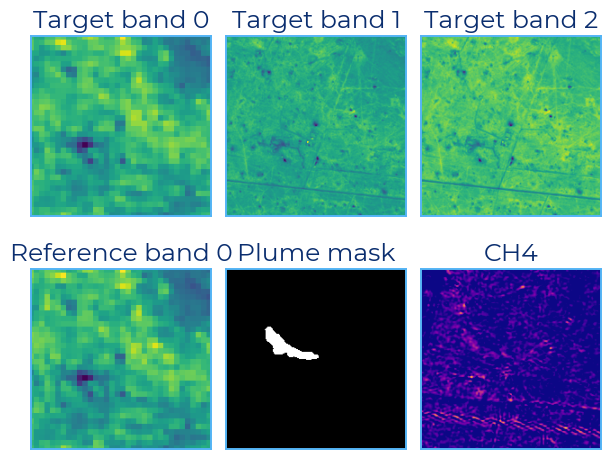

In [19]:
def show_array(ax, arr, title, cmap="viridis"):
    im = ax.imshow(arr, cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im

Target = Sample["Target"]
Reference = Sample["Reference"]
Plume = Sample["Plume"]

fig, axes = plt.subplots(2, 3, figsize=GetFigureSizeSafe("Wide", Fallback=(14, 8)))

show_array(axes[0,0], Target[0], "Target band 0")
show_array(axes[0,1], Target[min(1, Target.shape[0]-1)], "Target band 1")
show_array(axes[0,2], Target[min(2, Target.shape[0]-1)], "Target band 2")

show_array(axes[1,0], Reference[0], "Reference band 0")
show_array(axes[1,1], Plume, "Plume mask", cmap="gray")

if Sample.get("CH4") is not None:
    show_array(axes[1,2], Sample["CH4"], "CH4", cmap="plasma")
else:
    axes[1,2].axis("off")
    axes[1,2].set_title("CH4 unavailable")

plt.tight_layout()
plt.show()

## 9. ConfigB y features de teledetección

ConfigB utiliza 9 canales:

1. B8A.
2. B11.
3. B12.
4. NDSWIR.
5. RatioB12B11.
6. RatioB12B8A.
7. MBMP.
8. MBMPPlus.
9. DualEnhancementB12B11.

Decisión metodológica:

`MBMP = (TargetB12 - ReferenceB12) / ReferenceB12`.

`MBMPPlus` es una limpieza espacial no supervisada de MBMP.

No usa Plume, no usa GroundTruth y no usa máscara de fondo supervisada.

In [20]:
ConfigBPath = ProjectRoot / "Configs" / "ConfigB.yaml"
with open(ConfigBPath, "r", encoding="utf-8") as f:
    ConfigB = yaml.safe_load(f)

FeatureNames = ConfigB["Features"]

print("InputChannels:", ConfigB["InputChannels"])
print("FeatureNames:", FeatureNames)
print("MethodologicalNotes:")
display(ConfigB.get("MethodologicalNotes"))

InputChannels: 9
FeatureNames: ['B8A', 'B11', 'B12', 'NDSWIR', 'RatioB12B11', 'RatioB12B8A', 'MBMP', 'MBMPPlus', 'DualEnhancementB12B11']
MethodologicalNotes:


{'MBMPPlus': {'Variant': 'UnsupervisedRidgeCleaning',
  'UsesGroundTruthMask': False,
  'UsesPlumeMask': False,
  'UsesSupervisedBackgroundCorrection': False,
  'FormulaBase': 'MBMP = (TargetB12 - ReferenceB12) / ReferenceB12',
  'Cleaning': 'Spatial high-pass cleaning on MBMP using RidgeClean2D',
  'Purpose': 'Reduce smooth background/surface component without using label information.',
  'OperationalStatus': 'Suitable for inference because it only requires target/reference bands.'},
 'DualEnhancementB12B11': {'Formula': '(B12_target / B11_target) / (B12_reference / B11_reference) - 1',
  'Purpose': 'Enhance B12 change relative to B11 background variation.'}}

In [21]:
FeatureDict = BuildFeatureDictionary(
    Target=Sample["Target"],
    Reference=Sample["Reference"],
    FeatureConfig="ConfigB",
    PlumeMask=Sample["Plume"],  # Compatibilidad; no debe usarse para construir features.
)

for k, v in FeatureDict.items():
    print(k, v.shape, v.dtype, "min:", float(np.nanmin(v)), "max:", float(np.nanmax(v)))

Stack = BuildFeatureStack(
    Target=Sample["Target"],
    Reference=Sample["Reference"],
    FeatureNames=FeatureNames,
    FeatureConfig="ConfigB",
)

print("Stack:", Stack.shape, Stack.dtype)

B8A (200, 200) float32 min: 2885.0 max: 5089.0
B11 (200, 200) float32 min: 3033.0 max: 5504.0
B12 (200, 200) float32 min: 2516.0 max: 4552.0
NDSWIR (200, 200) float32 min: -0.1297910511493683 max: -0.06967637687921524
RatioB12B11 (200, 200) float32 min: 0.7702388763427734 max: 0.8697243928909302
RatioB12B8A (200, 200) float32 min: 0.7507728934288025 max: 1.1798205375671387
MBMP (200, 200) float32 min: -0.23772671818733215 max: 0.15960244834423065
MBMPPlus (200, 200) float32 min: -0.11633423715829849 max: 0.06481976807117462
DualEnhancementB12B11 (200, 200) float32 min: -0.05211383104324341 max: 0.041074514389038086
Stack: (9, 200, 200) float32


## 10. Visualización de features ConfigB

Se visualizan los nueve canales para una muestra.

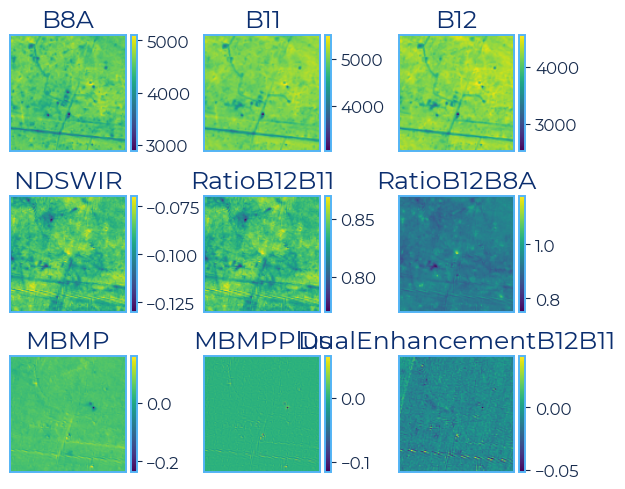

In [22]:
fig, axes = plt.subplots(3, 3, figsize=GetFigureSizeSafe("Large", Fallback=(13, 12)))
axes = axes.ravel()

for i, name in enumerate(FeatureNames):
    arr = FeatureDict[name]
    im = axes[i].imshow(arr, cmap="viridis")
    axes[i].set_title(name)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 11. Distribución preliminar de tamaños de pluma

Se calcula una estimación de píxeles positivos por muestra en una muestra parcial de cada split.

Para evitar que el notebook sea pesado, inicialmente se usan 100 muestras por split.

In [23]:
def compute_plume_pixels_for_split(split_name, max_samples=100):
    p = TablesRoot / f"Split{split_name}FeatureReady.csv"
    if not p.exists():
        return pd.DataFrame()

    df = pd.read_csv(p).head(max_samples)

    rows = []
    for i, row in df.iterrows():
        sid = str(row["SampleId"])
        s = ReadFullTacoSample(Dataset=Dataset, SampleTable=SampleTable, SampleId=sid)
        plume = (np.asarray(s["Plume"]) > 0).astype(np.uint8)
        rows.append({
            "Split": split_name,
            "SampleId": sid,
            "PlumePixels": int(plume.sum()),
            "PlumeFraction": float(plume.mean()),
        })

    return pd.DataFrame(rows)

PlumeStatsPreview = pd.concat([
    compute_plume_pixels_for_split("Train", max_samples=100),
    compute_plume_pixels_for_split("Validation", max_samples=100),
    compute_plume_pixels_for_split("Test", max_samples=100),
], ignore_index=True)

display(PlumeStatsPreview.head())
display(PlumeStatsPreview.groupby("Split")["PlumePixels"].describe())

,Split,SampleId,PlumePixels,PlumeFraction
0,Train,de030b00-e6b8-4984-8a38-e58575d4588c,1638,0.040950
1,Train,eed29b21-7a33-4cfd-8b93-20e5a2ed69ad,830,0.020750
2,Train,501f2901-74f0-4285-9c33-fa534af753b7,576,0.014400
3,Train,befa48b5-3652-4518-8e45-045c27e6bedc,242,0.006050
4,Train,bf262b0f-fc7c-4290-9091-b127e6bb1ed0,1447,0.036175


,count,mean,std,min,25%,50%,75%,max
Split,,,,,,,,
Test,100.0,1351.58,1049.104873,96.0,635.25,1005.0,1772.75,6332.0
Train,100.0,1388.76,1495.056920,154.0,614.50,830.0,1744.75,10827.0
Validation,100.0,1287.83,1388.279468,152.0,476.25,920.0,1557.00,10746.0


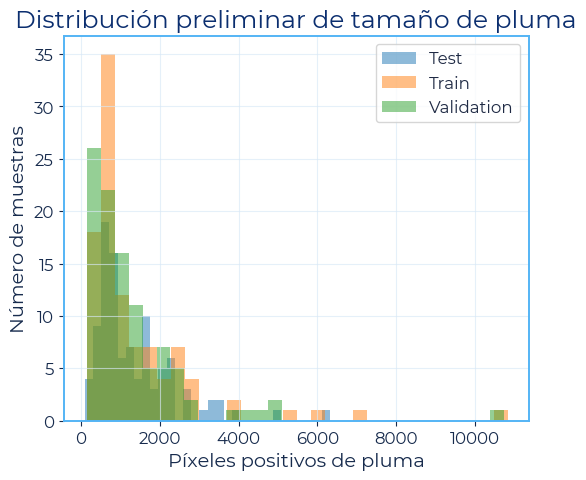

In [24]:
plt.figure(figsize=GetFigureSizeSafe("Wide", Fallback=(14, 8)))

for split, group in PlumeStatsPreview.groupby("Split"):
    plt.hist(group["PlumePixels"], bins=30, alpha=0.5, label=split)

plt.xlabel("Píxeles positivos de pluma")
plt.ylabel("Número de muestras")
plt.title("Distribución preliminar de tamaño de pluma")
plt.legend()
plt.show()

## 12. Tensores oficiales del pipeline

Se inspeccionan los tensores generados por `Step07BuildFeaturesClean.py`.

In [25]:
FeatureDir = ProjectRoot / "Outputs" / "Experiments" / RunTag / "ConfigB" / "Features"

for split in ["Train", "Validation", "Test"]:
    x_path = FeatureDir / f"{split}Features.npy"
    y_path = FeatureDir / f"{split}Masks.npy"

    print(split, x_path.exists(), y_path.exists())

    if x_path.exists() and y_path.exists():
        X = np.load(x_path, mmap_mode="r")
        Y = np.load(y_path, mmap_mode="r")
        print(" X:", X.shape, X.dtype, "min:", float(X.min()), "max:", float(X.max()))
        print(" Y:", Y.shape, Y.dtype, "positive:", int(Y.sum()))

Train True True


 X: (2463, 9, 200, 200) float32 min: -8.0 max: 8.0
 Y: (2463, 1, 200, 200) uint8 positive: 3131571
Validation True True
 X: (528, 9, 200, 200) float32 min: -8.0 max: 8.0
 Y: (528, 1, 200, 200) uint8 positive: 655526
Test True True
 X: (528, 9, 200, 200) float32 min: -8.0 max: 8.0
 Y: (528, 1, 200, 200) uint8 positive: 722109


## 13. Estadísticas por canal

Se calculan estadísticas básicas por canal para Train, Validation y Test.

Esto permite detectar saturación, valores extremos o diferencias fuertes entre splits.

In [26]:
def channel_stats(split):
    X = np.load(FeatureDir / f"{split}Features.npy", mmap_mode="r")
    rows = []

    for c, name in enumerate(FeatureNames):
        arr = X[:, c, :, :]
        rows.append({
            "Split": split,
            "Channel": c,
            "Feature": name,
            "Mean": float(arr.mean()),
            "Std": float(arr.std()),
            "Min": float(arr.min()),
            "Max": float(arr.max()),
            "P01": float(np.percentile(arr, 1)),
            "P50": float(np.percentile(arr, 50)),
            "P99": float(np.percentile(arr, 99)),
        })

    return pd.DataFrame(rows)

AllChannelStats = pd.concat([
    channel_stats("Train"),
    channel_stats("Validation"),
    channel_stats("Test"),
], ignore_index=True)

display(AllChannelStats)

,Split,Channel,Feature,Mean,Std,Min,Max,P01,P50,P99
0,Train,0,B8A,7.909204,0.847425,0.000000,8.000000,0.000000,8.000000e+00,8.000000
1,Train,1,B11,7.909130,0.847763,0.000000,8.000000,0.000000,8.000000e+00,8.000000
2,Train,2,B12,7.909166,0.847599,0.000000,8.000000,0.000000,8.000000e+00,8.000000
3,Train,3,NDSWIR,-0.072925,0.032316,-1.000000,1.000000,-0.167081,-7.084198e-02,0.000000
4,Train,4,RatioB12B11,0.854363,0.106752,0.000000,8.000000,0.000000,8.662999e-01,0.955366
5,Train,5,RatioB12B8A,1.012093,0.146889,0.000000,8.000000,0.000000,1.029473e+00,1.181995
6,Train,6,MBMP,0.042755,0.621703,-1.000000,8.000000,-0.430690,-1.618996e-03,0.539474
7,Train,7,MBMPPlus,0.000814,0.603325,-8.000000,8.000000,-0.036346,0.000000e+00,0.036594
8,Train,8,DualEnhancementB12B11,0.034960,0.612534,-1.000000,8.000000,-1.000000,-3.735423e-04,0.106786
9,Validation,0,B8A,7.954545,0.601314,0.000000,8.000000,8.000000,8.000000e+00,8.000000


In [27]:
display(AllChannelStats.pivot(index="Feature", columns="Split", values="Mean"))
display(AllChannelStats.pivot(index="Feature", columns="Split", values="Std"))

Split,Test,Train,Validation
Feature,,,
B11,7.969697,7.909130,7.954545
B12,7.969697,7.909166,7.954545
B8A,7.969697,7.909204,7.954545
DualEnhancementB12B11,0.028146,0.034960,0.009167
MBMP,0.034838,0.042755,0.013750
MBMPPlus,0.000348,0.000814,0.000572
NDSWIR,-0.074436,-0.072925,-0.074673
RatioB12B11,0.859157,0.854363,0.856941
RatioB12B8A,1.021669,1.012093,1.017181


Split,Test,Train,Validation
Feature,,,
B11,0.491432,0.847763,0.601314
B12,0.491432,0.847599,0.601314
B8A,0.491432,0.847425,0.601314
DualEnhancementB12B11,0.496295,0.612534,0.357506
MBMP,0.504330,0.621703,0.367983
MBMPPlus,0.492561,0.603325,0.348425
NDSWIR,0.030818,0.032316,0.031800
RatioB12B11,0.074170,0.106752,0.083725
RatioB12B8A,0.114195,0.146889,0.127376


## 14. Conclusiones preliminares del EDA

Completar después de ejecutar el notebook:

- Disponibilidad y consistencia de productos.
- Distribución de tamaños de pluma.
- Desbalance de clases.
- Rangos de las features.
- Justificación de MBMPPlus no supervisado.
- Comparabilidad entre Train, Validation y Test.
- Riesgos metodológicos evitados al no usar GroundTruth en features.

Notas para tesis:

- El dataset se divide en entrenamiento, validación y prueba antes del entrenamiento.
- La máscara de pluma se usa como variable objetivo de segmentación.
- Las variables de entrada se construyen únicamente desde bandas Target y Reference.
- La versión no supervisada de MBMPPlus evita fuga de información desde la etiqueta hacia las features.
- Esta decisión permite que el pipeline sea compatible con inferencia real, donde no existe máscara de pluma conocida.

## 25. Figuras EDA listas para documentación

Las siguientes figuras resumen patrones de teledetección de forma más adecuada para el documento final.

Se exportan automáticamente a:

`Outputs/Experiments/<RunTag>/EDA/Figures/`

### 25.0 Carga segura de tablas EDA

Esta celda permite ejecutar las figuras documentables aunque el kernel se haya reiniciado.

In [28]:
# =============================================================================
# Build advanced EDA tables if missing
# =============================================================================

EDAOutDir = ProjectRoot / "Outputs" / "Experiments" / RunTag / "EDA"
EDAOutDir.mkdir(parents=True, exist_ok=True)

required_eda_files = {
    "BandRegionStats": EDAOutDir / "BandFeatureRegionStats.csv",
    "AggregateStats": EDAOutDir / "AggregateBandFeatureRegionStats.csv",
    "PlumeContrastStats": EDAOutDir / "PlumeContrastStats.csv",
    "ContrastSummary": EDAOutDir / "PlumeBackgroundContrastSummary.csv",
    "OutlierSummary": EDAOutDir / "OutlierSummaryByVariableRegion.csv",
    "PixelSamples": EDAOutDir / "PixelSamplesForCorrelation.csv",
}

missing_files = [name for name, path in required_eda_files.items() if not path.exists()]

print("Missing EDA files:", missing_files)

if missing_files:
    print("Building advanced EDA tables...")

    MaxSamplesPerSplitEDA = 80
    MaxPixelsPerRegionPerSample = 300
    RandomSeedEDA = 42
    rng = np.random.default_rng(RandomSeedEDA)

    from Source import FeatureEngineering as fe

    def safe_get_band(array, band_name):
        if hasattr(fe, "GetBand"):
            try:
                return fe.GetBand(array, band_name)
            except Exception:
                pass

        fallback_map = {
            "B8A": 0,
            "B11": 1,
            "B12": 2,
        }

        idx = fallback_map[band_name]
        return np.asarray(array[idx], dtype=np.float32)

    def summarize_values(values):
        values = np.asarray(values, dtype=np.float32)
        values = values[np.isfinite(values)]

        if values.size == 0:
            return {
                "Count": 0,
                "Mean": np.nan,
                "Std": np.nan,
                "Min": np.nan,
                "P01": np.nan,
                "P05": np.nan,
                "P25": np.nan,
                "P50": np.nan,
                "P75": np.nan,
                "P95": np.nan,
                "P99": np.nan,
                "Max": np.nan,
                "IQR": np.nan,
            }

        q = np.percentile(values, [1, 5, 25, 50, 75, 95, 99])
        return {
            "Count": int(values.size),
            "Mean": float(np.mean(values)),
            "Std": float(np.std(values)),
            "Min": float(np.min(values)),
            "P01": float(q[0]),
            "P05": float(q[1]),
            "P25": float(q[2]),
            "P50": float(q[3]),
            "P75": float(q[4]),
            "P95": float(q[5]),
            "P99": float(q[6]),
            "Max": float(np.max(values)),
            "IQR": float(q[4] - q[2]),
        }

    def build_region_masks(plume):
        plume_mask = np.asarray(plume) > 0
        return {
            "All": np.ones_like(plume_mask, dtype=bool),
            "Plume": plume_mask,
            "Background": ~plume_mask,
        }

    def get_sample_variables(sample):
        target = sample["Target"]
        reference = sample["Reference"]

        feature_dict = BuildFeatureDictionary(
            Target=target,
            Reference=reference,
            FeatureConfig="ConfigB",
            PlumeMask=sample["Plume"],
        )

        variables = {}

        for band in ["B8A", "B11", "B12"]:
            variables[f"Target_{band}"] = safe_get_band(target, band)
            variables[f"Reference_{band}"] = safe_get_band(reference, band)
            variables[f"Delta_{band}"] = safe_get_band(target, band) - safe_get_band(reference, band)

        for name in FeatureNames:
            if name in feature_dict:
                variables[f"Feature_{name}"] = np.asarray(feature_dict[name], dtype=np.float32)

        return variables

    def load_split_sample_ids(split, max_samples):
        path = TablesRoot / f"Split{split}FeatureReady.csv"
        df = pd.read_csv(path)
        return df["SampleId"].astype(str).head(max_samples).tolist()

    eda_sample_rows = []

    for split in ["Train", "Validation", "Test"]:
        ids = load_split_sample_ids(split, MaxSamplesPerSplitEDA)
        for sid in ids:
            eda_sample_rows.append({
                "Split": split,
                "SampleId": sid,
            })

    EDASampleTable = pd.DataFrame(eda_sample_rows)

    stats_rows = []
    contrast_rows = []
    pixel_rows = []

    for row_idx, row in EDASampleTable.iterrows():
        split = row["Split"]
        sample_id = row["SampleId"]

        sample = ReadFullTacoSample(
            Dataset=Dataset,
            SampleTable=SampleTable,
            SampleId=sample_id,
        )

        plume = np.asarray(sample["Plume"])
        masks = build_region_masks(plume)
        variables = get_sample_variables(sample)

        plume_pixels = int(masks["Plume"].sum())
        background_pixels = int(masks["Background"].sum())

        if (row_idx + 1) % 20 == 0 or row_idx == 0:
            print(f"{row_idx + 1}/{len(EDASampleTable)} | {split} | plume pixels={plume_pixels}")

        for var_name, arr in variables.items():
            arr = np.asarray(arr, dtype=np.float32)

            for region_name, region_mask in masks.items():
                vals = arr[region_mask]
                s = summarize_values(vals)
                s.update({
                    "Split": split,
                    "SampleId": sample_id,
                    "Variable": var_name,
                    "Region": region_name,
                    "PlumePixels": plume_pixels,
                    "BackgroundPixels": background_pixels,
                })
                stats_rows.append(s)

            plume_vals = arr[masks["Plume"]]
            background_vals = arr[masks["Background"]]

            plume_stats = summarize_values(plume_vals)
            bg_stats = summarize_values(background_vals)

            contrast_rows.append({
                "Split": split,
                "SampleId": sample_id,
                "Variable": var_name,
                "PlumePixels": plume_pixels,
                "BackgroundPixels": background_pixels,
                "PlumeMean": plume_stats["Mean"],
                "BackgroundMean": bg_stats["Mean"],
                "MeanDifference_PlumeMinusBackground": plume_stats["Mean"] - bg_stats["Mean"],
                "StandardizedContrast": (
                    (plume_stats["Mean"] - bg_stats["Mean"]) / (bg_stats["Std"] + 1e-6)
                    if np.isfinite(bg_stats["Std"]) else np.nan
                ),
                "PlumeMedian": plume_stats["P50"],
                "BackgroundMedian": bg_stats["P50"],
                "MedianDifference_PlumeMinusBackground": plume_stats["P50"] - bg_stats["P50"],
            })

        for region_name in ["Plume", "Background"]:
            region_mask = masks[region_name]
            coords = np.argwhere(region_mask)

            if coords.shape[0] == 0:
                continue

            take = min(MaxPixelsPerRegionPerSample, coords.shape[0])
            chosen = coords[rng.choice(coords.shape[0], size=take, replace=False)]

            for y, x in chosen:
                px = {
                    "Split": split,
                    "SampleId": sample_id,
                    "Region": region_name,
                    "Y": int(y),
                    "X": int(x),
                    "PlumePixels": plume_pixels,
                }

                for var_name, arr in variables.items():
                    value = float(arr[y, x])
                    px[var_name] = value if np.isfinite(value) else np.nan

                pixel_rows.append(px)

    BandRegionStats = pd.DataFrame(stats_rows)
    PlumeContrastStats = pd.DataFrame(contrast_rows)
    PixelSamples = pd.DataFrame(pixel_rows)

    AggregateStats = (
        BandRegionStats
        .groupby(["Split", "Variable", "Region"], as_index=False)
        .agg(
            Samples=("SampleId", "nunique"),
            MeanOfMeans=("Mean", "mean"),
            MedianOfMedians=("P50", "median"),
            MeanStd=("Std", "mean"),
            MeanP01=("P01", "mean"),
            MeanP99=("P99", "mean"),
            TotalCount=("Count", "sum"),
        )
    )

    ContrastSummary = (
        PlumeContrastStats
        .groupby(["Split", "Variable"], as_index=False)
        .agg(
            Samples=("SampleId", "nunique"),
            MeanDifference=("MeanDifference_PlumeMinusBackground", "mean"),
            MedianDifference=("MedianDifference_PlumeMinusBackground", "median"),
            MeanStandardizedContrast=("StandardizedContrast", "mean"),
            MedianStandardizedContrast=("StandardizedContrast", "median"),
        )
    )

    numeric_cols = [
        c for c in PixelSamples.columns
        if c not in ["Split", "SampleId", "Region", "Y", "X", "PlumePixels"]
    ]

    outlier_rows = []

    for var in numeric_cols:
        vals = PixelSamples[var].dropna().values
        if vals.size == 0:
            continue

        q1, q3 = np.percentile(vals, [25, 75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        tmp = PixelSamples[["Split", "Region", var]].copy()
        tmp["IsOutlier"] = (tmp[var] < lower) | (tmp[var] > upper)

        summary = (
            tmp
            .groupby(["Split", "Region"], as_index=False)
            .agg(
                PixelCount=(var, "count"),
                OutlierPixels=("IsOutlier", "sum"),
            )
        )

        summary["Variable"] = var
        summary["LowerFence"] = lower
        summary["UpperFence"] = upper
        summary["OutlierFraction"] = summary["OutlierPixels"] / summary["PixelCount"].replace(0, np.nan)

        outlier_rows.append(summary)

    OutlierSummary = pd.concat(outlier_rows, ignore_index=True)

    BandRegionStats.to_csv(required_eda_files["BandRegionStats"], index=False)
    AggregateStats.to_csv(required_eda_files["AggregateStats"], index=False)
    PlumeContrastStats.to_csv(required_eda_files["PlumeContrastStats"], index=False)
    ContrastSummary.to_csv(required_eda_files["ContrastSummary"], index=False)
    OutlierSummary.to_csv(required_eda_files["OutlierSummary"], index=False)
    PixelSamples.to_csv(required_eda_files["PixelSamples"], index=False)

    print("Advanced EDA tables built and saved.")

else:
    print("All advanced EDA tables already exist. Loading...")

    BandRegionStats = pd.read_csv(required_eda_files["BandRegionStats"])
    AggregateStats = pd.read_csv(required_eda_files["AggregateStats"])
    PlumeContrastStats = pd.read_csv(required_eda_files["PlumeContrastStats"])
    ContrastSummary = pd.read_csv(required_eda_files["ContrastSummary"])
    OutlierSummary = pd.read_csv(required_eda_files["OutlierSummary"])
    PixelSamples = pd.read_csv(required_eda_files["PixelSamples"])

print("Ready:")
print("BandRegionStats:", BandRegionStats.shape)
print("AggregateStats:", AggregateStats.shape)
print("PlumeContrastStats:", PlumeContrastStats.shape)
print("ContrastSummary:", ContrastSummary.shape)
print("OutlierSummary:", OutlierSummary.shape)
print("PixelSamples:", PixelSamples.shape)

Missing EDA files: ['BandRegionStats', 'AggregateStats', 'PlumeContrastStats', 'ContrastSummary', 'OutlierSummary', 'PixelSamples']
Building advanced EDA tables...
1/240 | Train | plume pixels=1638
20/240 | Train | plume pixels=2738
40/240 | Train | plume pixels=617
60/240 | Train | plume pixels=716
80/240 | Train | plume pixels=311
100/240 | Validation | plume pixels=630
120/240 | Validation | plume pixels=1010
140/240 | Validation | plume pixels=1308
160/240 | Validation | plume pixels=449
180/240 | Test | plume pixels=2281
200/240 | Test | plume pixels=1899
220/240 | Test | plume pixels=1742
240/240 | Test | plume pixels=1859
Advanced EDA tables built and saved.
Ready:
BandRegionStats: (12960, 19)
AggregateStats: (162, 10)
PlumeContrastStats: (4320, 12)
ContrastSummary: (54, 7)
OutlierSummary: (108, 8)
PixelSamples: (143095, 24)


In [29]:
# =============================================================================
# Load advanced EDA tables if they are not already in memory
# =============================================================================

EDAOutDir = ProjectRoot / "Outputs" / "Experiments" / RunTag / "EDA"
FIGURE_DIR = EDAOutDir / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def _load_csv_if_missing(var_name, filename):
    if var_name in globals():
        print(f"{var_name}: already in memory")
        return globals()[var_name]

    path = EDAOutDir / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Ejecuta primero las secciones 15 a 24 del notebook "
            f"para construir las tablas EDA avanzadas."
        )

    df = pd.read_csv(path)
    globals()[var_name] = df
    print(f"{var_name}: loaded from {path} | shape={df.shape}")
    return df

BandRegionStats = _load_csv_if_missing(
    "BandRegionStats",
    "BandFeatureRegionStats.csv",
)

AggregateStats = _load_csv_if_missing(
    "AggregateStats",
    "AggregateBandFeatureRegionStats.csv",
)

PlumeContrastStats = _load_csv_if_missing(
    "PlumeContrastStats",
    "PlumeContrastStats.csv",
)

ContrastSummary = _load_csv_if_missing(
    "ContrastSummary",
    "PlumeBackgroundContrastSummary.csv",
)

OutlierSummary = _load_csv_if_missing(
    "OutlierSummary",
    "OutlierSummaryByVariableRegion.csv",
)

PixelSamples = _load_csv_if_missing(
    "PixelSamples",
    "PixelSamplesForCorrelation.csv",
)

print("Advanced EDA tables ready.")

BandRegionStats: already in memory
AggregateStats: already in memory
PlumeContrastStats: already in memory
ContrastSummary: already in memory
OutlierSummary: already in memory
PixelSamples: already in memory
Advanced EDA tables ready.


### 25.1 Contraste pluma-fondo por feature

Esta figura resume qué variables cambian más dentro de la pluma respecto al fondo.

Se usa el contraste estandarizado medio:

`(media_pluma - media_fondo) / desviación_fondo`

Saved figure: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/Figures/EDA_Contrast_Plume_vs_Background_byFeature.png


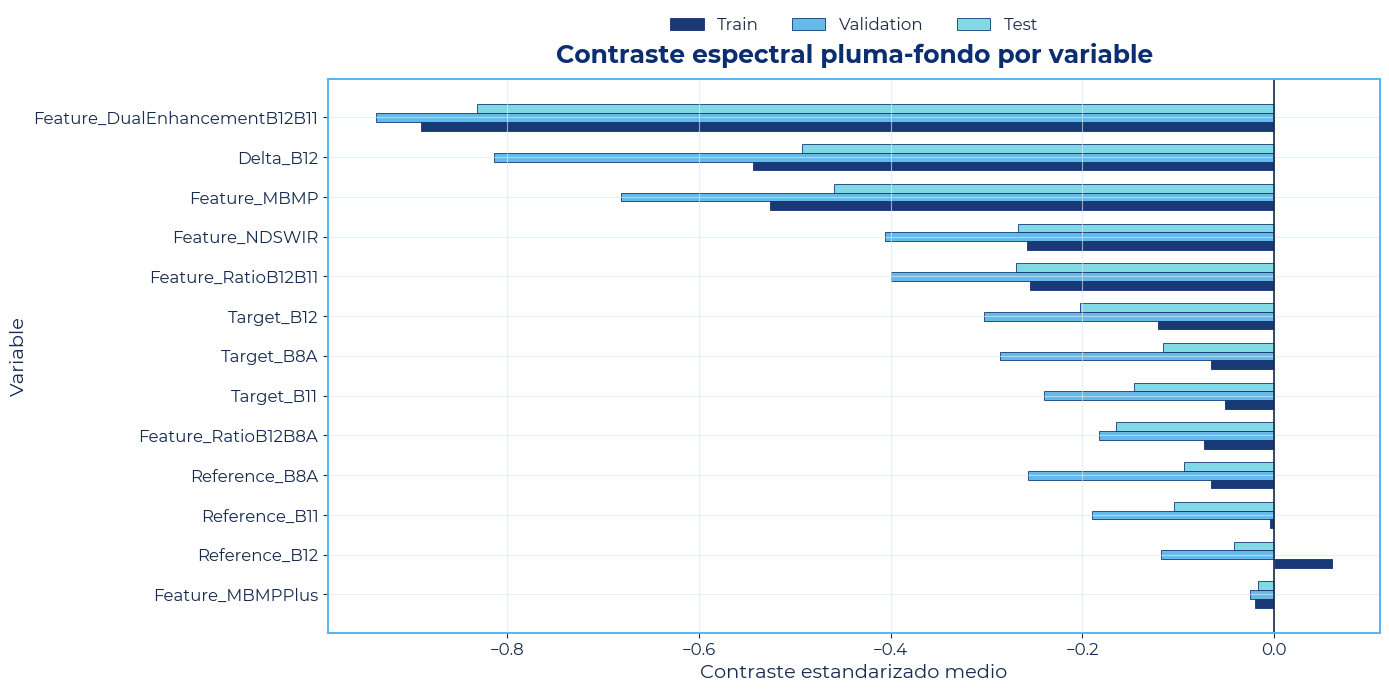

In [30]:
# Figura 25.1 - Contraste estandarizado pluma vs fondo

contrast_plot_df = ContrastSummary.copy()

preferred_vars = [
    "Target_B8A",
    "Target_B11",
    "Target_B12",
    "Reference_B8A",
    "Reference_B11",
    "Reference_B12",
    "Delta_B12",
    "Feature_NDSWIR",
    "Feature_RatioB12B11",
    "Feature_RatioB12B8A",
    "Feature_MBMP",
    "Feature_MBMPPlus",
    "Feature_DualEnhancementB12B11",
]

available_vars = [v for v in preferred_vars if v in contrast_plot_df["Variable"].unique()]
contrast_plot_df = contrast_plot_df[contrast_plot_df["Variable"].isin(available_vars)]

# Orden por magnitud promedio en todos los splits.
var_order = (
    contrast_plot_df
    .groupby("Variable")["MeanStandardizedContrast"]
    .mean()
    .abs()
    .sort_values(ascending=True)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=GetThesisFigSize("wide"))

bar_height = 0.22
y = np.arange(len(var_order))

for idx, split in enumerate(["Train", "Validation", "Test"]):
    tmp = (
        contrast_plot_df[contrast_plot_df["Split"] == split]
        .set_index("Variable")
        .reindex(var_order)
    )
    offset = (idx - 1) * bar_height
    ax.barh(
        y + offset,
        tmp["MeanStandardizedContrast"],
        height=bar_height,
        label=split,
        color=SPLIT_COLORS.get(split),
        edgecolor=COLORS["navy"],
        linewidth=0.6,
        alpha=0.95,
    )

ax.axvline(0, color=COLORS["text"], linewidth=1.2)
ax.set_yticks(y)
ax.set_yticklabels(var_order)
StyleAxes(
    ax,
    title="Contraste espectral pluma-fondo por variable",
    xlabel="Contraste estandarizado medio",
    ylabel="Variable",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.14), ncol=3, frameon=False)
plt.tight_layout()
SaveFigure(fig, "EDA_Contrast_Plume_vs_Background_byFeature.png")
plt.show()

### 25.2 Heatmap de contraste por split

Este mapa de calor permite identificar rápidamente qué variables son más discriminantes y si el patrón es consistente entre Train, Validation y Test.

Saved figure: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/Figures/EDA_Heatmap_PlumeBackgroundContrast.png


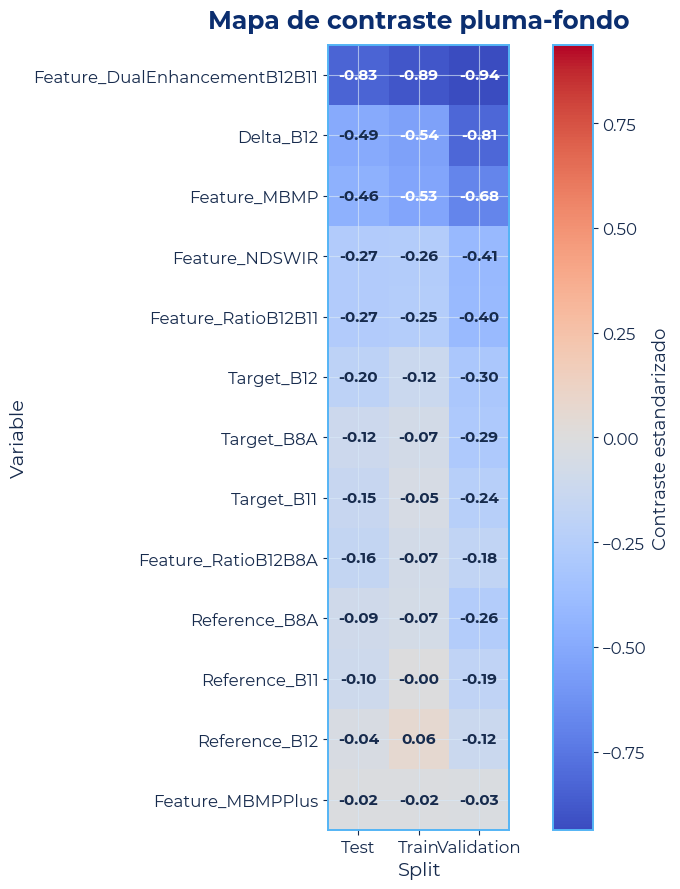

In [31]:
# Figura 25.2 - Heatmap de contraste por split

heat_df = (
    ContrastSummary[
        ContrastSummary["Variable"].isin(available_vars)
    ]
    .pivot(index="Variable", columns="Split", values="MeanStandardizedContrast")
    .reindex(var_order[::-1])
)

fig, ax = plt.subplots(figsize=GetThesisFigSize("heatmap"))

vmax = np.nanmax(np.abs(heat_df.values))
vmax = max(vmax, 1e-6)

im = ax.imshow(heat_df.values, cmap="coolwarm", vmin=-vmax, vmax=vmax)

ax.set_xticks(np.arange(len(heat_df.columns)))
ax.set_xticklabels(heat_df.columns)
ax.set_yticks(np.arange(len(heat_df.index)))
ax.set_yticklabels(heat_df.index)

for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        val = heat_df.iloc[i, j]
        if np.isfinite(val):
            color = "white" if abs(val) > 0.55 * vmax else COLORS["text"]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=11, fontweight="bold")

StyleAxes(
    ax,
    title="Mapa de contraste pluma-fondo",
    xlabel="Split",
    ylabel="Variable",
)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Contraste estandarizado", fontsize=13)

plt.tight_layout()
SaveFigure(fig, "EDA_Heatmap_PlumeBackgroundContrast.png")
plt.show()

### 25.3 Distribuciones comparadas de variables clave

Se comparan las distribuciones de pluma y fondo para variables relevantes de ConfigB.

El recorte visual entre percentiles 1 y 99 evita que unos pocos valores extremos oculten la forma general de la distribución.

Saved figure: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/Figures/EDA_Distributions_Plume_vs_Background_KeyVariables.png


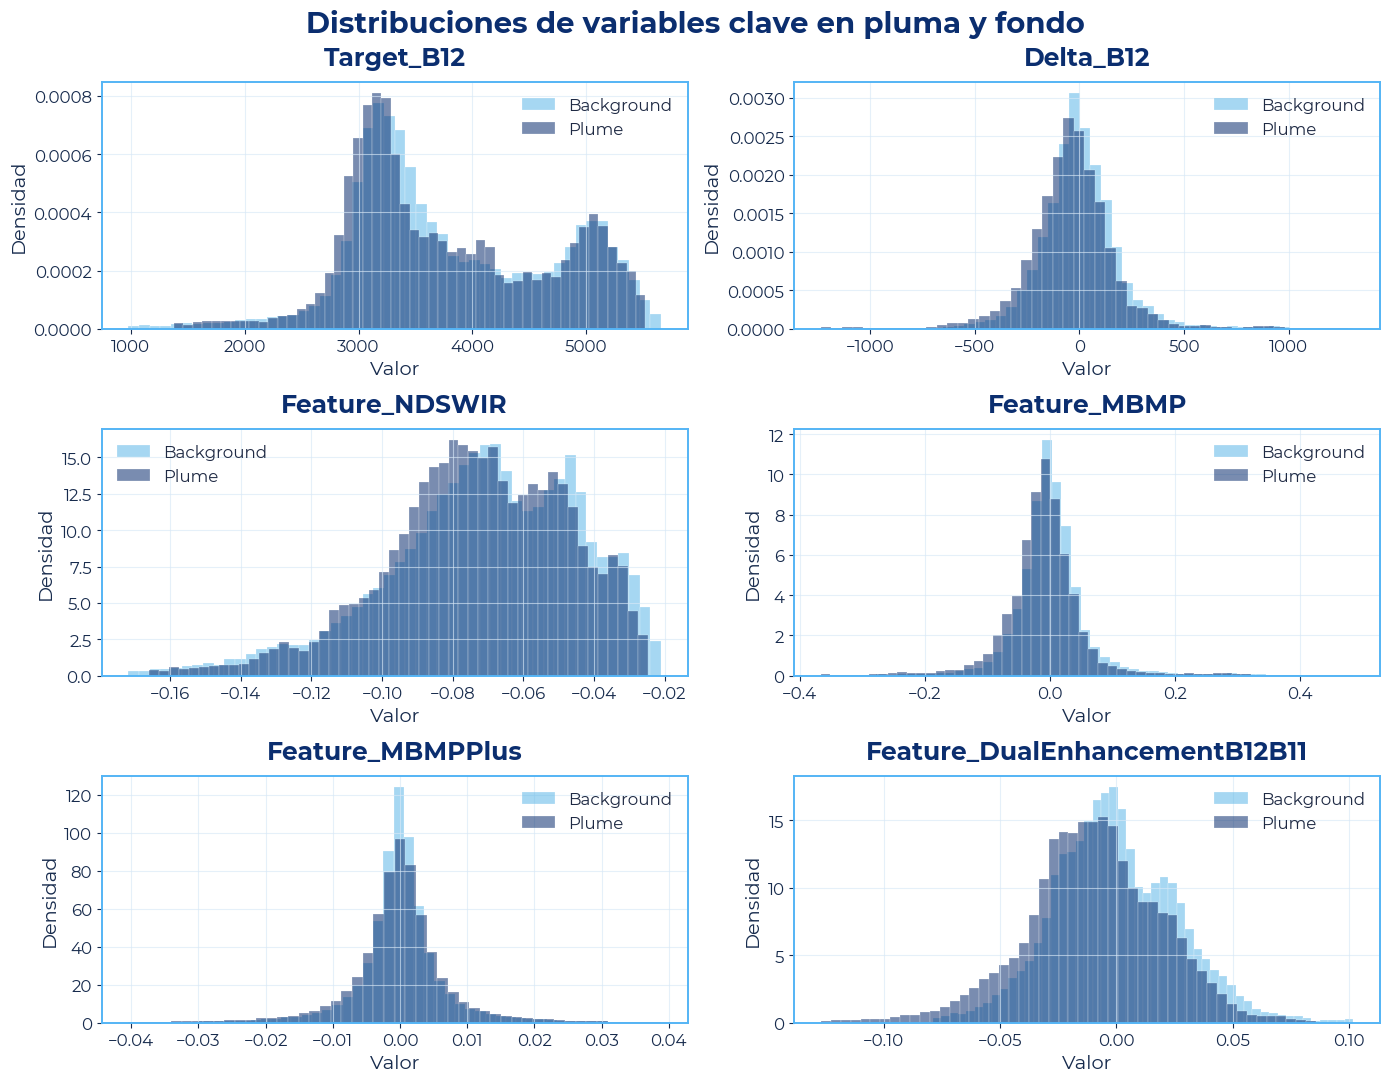

In [32]:
# Figura 25.3 - Distribuciones pluma vs fondo en variables clave

distribution_vars = [
    "Target_B12",
    "Delta_B12",
    "Feature_NDSWIR",
    "Feature_MBMP",
    "Feature_MBMPPlus",
    "Feature_DualEnhancementB12B11",
]
distribution_vars = [v for v in distribution_vars if v in PixelSamples.columns]

n = len(distribution_vars)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=GetThesisFigSize("large"))
axes = np.asarray(axes).ravel()

for ax, var in zip(axes, distribution_vars):
    for region in ["Background", "Plume"]:
        vals = PixelSamples.loc[PixelSamples["Region"] == region, var].dropna().values

        if vals.size == 0:
            continue

        lo, hi = np.percentile(vals, [1, 99])
        vals_clip = vals[(vals >= lo) & (vals <= hi)]

        ax.hist(
            vals_clip,
            bins=50,
            density=True,
            alpha=0.55,
            label=region,
            color=REGION_COLORS.get(region),
            edgecolor="white",
            linewidth=0.3,
        )

    StyleAxes(ax, title=var, xlabel="Valor", ylabel="Densidad")
    ax.legend(frameon=False)

for ax in axes[len(distribution_vars):]:
    ax.axis("off")

fig.suptitle("Distribuciones de variables clave en pluma y fondo", fontsize=21, fontweight="bold", color=COLORS["navy"])
plt.tight_layout()
SaveFigure(fig, "EDA_Distributions_Plume_vs_Background_KeyVariables.png")
plt.show()

### 25.4 Correlación entre bandas y features

Se presenta la correlación de Pearson entre bandas/features usando píxeles muestreados.

Esta figura ayuda a identificar redundancia entre variables y posibles grupos de información espectral.

Saved figure: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/Figures/EDA_Correlation_Bands_Features_AllSampled.png


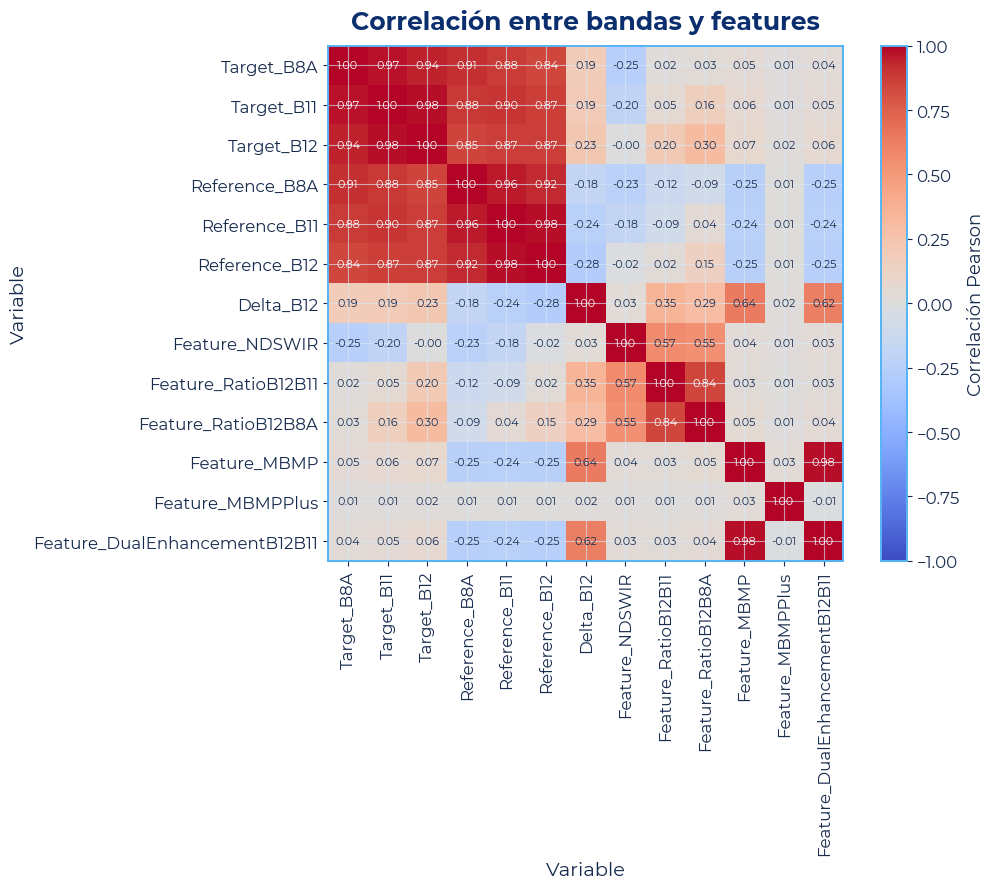

In [33]:
# Figura 25.4 - Correlación global de variables

corr_variables_doc = [
    "Target_B8A",
    "Target_B11",
    "Target_B12",
    "Reference_B8A",
    "Reference_B11",
    "Reference_B12",
    "Delta_B12",
    "Feature_NDSWIR",
    "Feature_RatioB12B11",
    "Feature_RatioB12B8A",
    "Feature_MBMP",
    "Feature_MBMPPlus",
    "Feature_DualEnhancementB12B11",
]
corr_variables_doc = [v for v in corr_variables_doc if v in PixelSamples.columns]

corr_doc = PixelSamples[corr_variables_doc].corr(method="pearson")

fig, ax = plt.subplots(figsize=GetThesisFigSize("heatmap"))

im = ax.imshow(corr_doc.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr_doc.columns)))
ax.set_xticklabels(corr_doc.columns, rotation=90)
ax.set_yticks(np.arange(len(corr_doc.index)))
ax.set_yticklabels(corr_doc.index)

for i in range(corr_doc.shape[0]):
    for j in range(corr_doc.shape[1]):
        val = corr_doc.iloc[i, j]
        if np.isfinite(val):
            color = "white" if abs(val) > 0.65 else COLORS["text"]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

StyleAxes(
    ax,
    title="Correlación entre bandas y features",
    xlabel="Variable",
    ylabel="Variable",
)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlación Pearson", fontsize=13)

plt.tight_layout()
SaveFigure(fig, "EDA_Correlation_Bands_Features_AllSampled.png")
plt.show()

### 25.5 Valores atípicos por variable y región

Esta figura resume la fracción de píxeles atípicos por variable y región, usando la regla IQR.

Permite identificar variables con colas fuertes o comportamiento extremo que puedan afectar el entrenamiento.

Saved figure: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/Figures/EDA_OutlierFraction_ByVariableRegion_Test.png


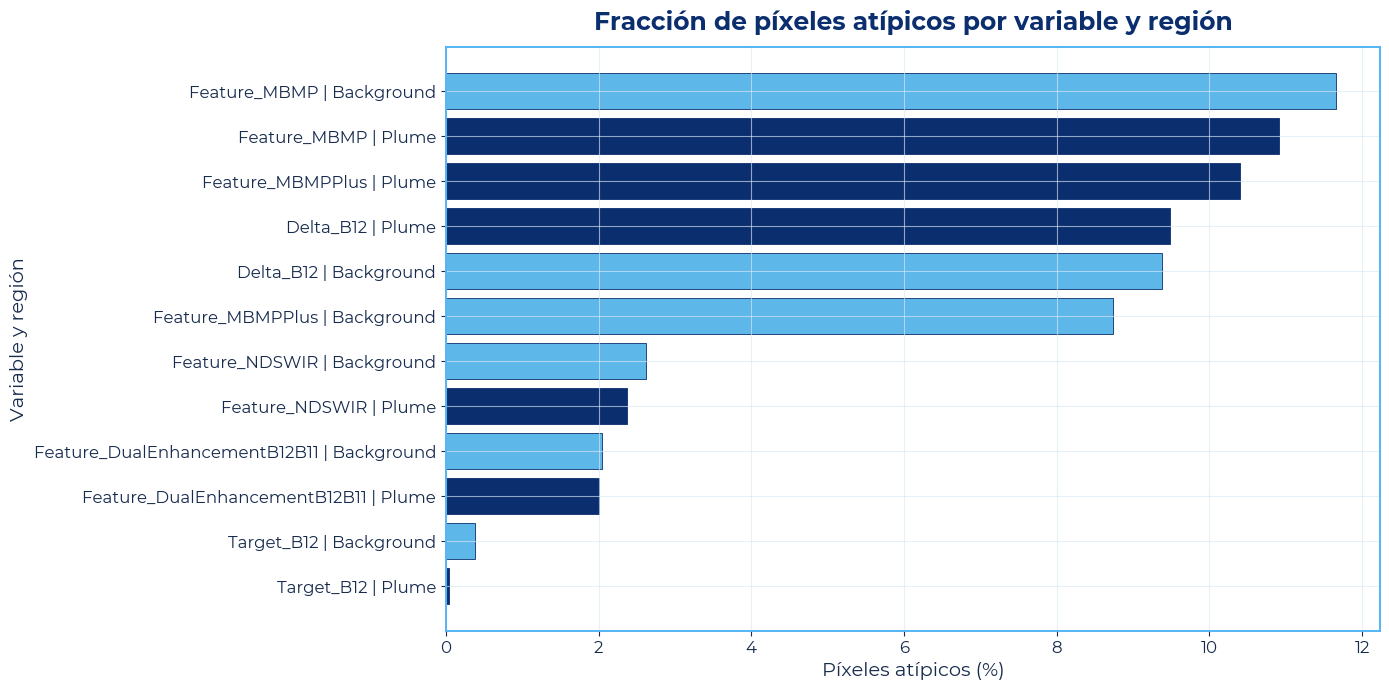

In [34]:
# Figura 25.5 - Outliers por variable y región

outlier_doc_vars = [
    "Target_B12",
    "Delta_B12",
    "Feature_NDSWIR",
    "Feature_MBMP",
    "Feature_MBMPPlus",
    "Feature_DualEnhancementB12B11",
]
outlier_doc_vars = [v for v in outlier_doc_vars if v in OutlierSummary["Variable"].unique()]

outlier_plot = OutlierSummary[
    (OutlierSummary["Split"] == "Test") &
    (OutlierSummary["Region"].isin(["Background", "Plume"])) &
    (OutlierSummary["Variable"].isin(outlier_doc_vars))
].copy()

outlier_plot["Label"] = outlier_plot["Variable"] + " | " + outlier_plot["Region"]
outlier_plot = outlier_plot.sort_values("OutlierFraction")

fig, ax = plt.subplots(figsize=GetThesisFigSize("wide"))

colors = [
    REGION_COLORS["Plume"] if "Plume" in label else REGION_COLORS["Background"]
    for label in outlier_plot["Label"]
]

ax.barh(
    outlier_plot["Label"],
    outlier_plot["OutlierFraction"] * 100,
    color=colors,
    edgecolor=COLORS["navy"],
    linewidth=0.6,
)

StyleAxes(
    ax,
    title="Fracción de píxeles atípicos por variable y región",
    xlabel="Píxeles atípicos (%)",
    ylabel="Variable y región",
)

plt.tight_layout()
SaveFigure(fig, "EDA_OutlierFraction_ByVariableRegion_Test.png")
plt.show()

## 26. Interpretación preliminar para el documento

Esta celda queda como guía para redactar conclusiones una vez ejecutadas las figuras anteriores.

Aspectos a revisar:

- Variables con mayor contraste positivo o negativo en la pluma.
- Consistencia del contraste entre Train, Validation y Test.
- Redundancia entre MBMP y MBMPPlus.
- Aporte diferencial de NDSWIR y DualEnhancementB12B11.
- Variables con alta presencia de outliers.
- Riesgos de sobreajuste por variables muy correlacionadas.
- Evidencia de que ConfigB aporta información espectral útil sin usar GroundTruth como entrada.